<a target="_blank" href="https://colab.research.google.com/github/justin45359-hue/seoul-commercial-area-analysis/blob/main/seoul_commercial_analysis_colab.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# 서울시 상권별 유망 업종 분석

**목적:** 2025년 서울시 상권 추정매출 데이터로 `어떤 업종이 어떤 상권에서 강한가`를 확인한다.

**제한:** `ComPhy-1-Python(1).ipynb`의 기본 Python 문법과 `ComPhy-3-Matplotlib.ipynb`의 Matplotlib만 사용한다. `pandas`, `seaborn`, `scikit-learn`은 사용하지 않는다.

In [ ]:
# Colab에서 CSV 파일을 업로드하는 실행 준비 코드입니다.
# 분석 코드는 다음 셀부터 시작합니다.
from google.colab import files
uploaded = files.upload()


In [1]:
# Seoul Commercial Area × Industry Analysis (2025)
# Lesson scope:
# ComPhy-1-Python(1).ipynb: open(), while, for, list, dictionary, if, function
# ComPhy-3-Matplotlib.ipynb: plt.subplots(), ax.bar(), ax.plot(), ax.legend()
# No pandas, seaborn, scikit-learn, ROOT, or other data-analysis packages.

import matplotlib.pyplot as plt

# Put this notebook in the same folder as the CSV file.
DATA_FILE = "서울시 상권분석서비스(추정매출-상권)_2025년.csv"


## 1. 파일 읽기 및 4개 분기 매출 누적

In [2]:
# 1. Read the CSV one line at a time.
# The file is CP949 encoded. Each field is quoted, so we split after
# removing the first and last quotation marks.

pair_data = {}
line_count = 0

with open(DATA_FILE, encoding="cp949") as fp:
    header_line = fp.readline()
    header = header_line.strip()[1:-1].split('","')

    line = fp.readline()
    while line:
        row = line.strip()[1:-1].split('","')

        # Positions from the uploaded CSV header
        quarter_code = row[0]          # 기준_년분기_코드, e.g. 20251
        market_type = row[2]           # 상권_구분_코드_명
        market_code = row[3]           # 상권_코드
        market_name = row[4]           # 상권_코드_명
        industry_code = row[5]         # 서비스_업종_코드
        industry_name = row[6]         # 서비스_업종_코드_명
        sales = int(row[7])            # 당월_매출_금액
        transactions = int(row[8])     # 당월_매출_건수

        quarter_number = int(quarter_code[-1])
        pair_key = market_type + "|" + market_code + "|" + industry_code

        if pair_key not in pair_data:
            # [type, code, name, industry code, industry name,
            #  annual sales, annual transactions,
            #  Q1 sales, Q2 sales, Q3 sales, Q4 sales, reported quarters]
            pair_data[pair_key] = [
                market_type, market_code, market_name, industry_code, industry_name,
                0, 0, 0, 0, 0, 0, 0
            ]

        pair_data[pair_key][5] = pair_data[pair_key][5] + sales
        pair_data[pair_key][6] = pair_data[pair_key][6] + transactions
        pair_data[pair_key][6 + quarter_number] = pair_data[pair_key][6 + quarter_number] + sales
        pair_data[pair_key][11] = pair_data[pair_key][11] + 1

        line_count = line_count + 1
        line = fp.readline()

print("Rows read =", line_count)
print("Market-industry pairs =", len(pair_data))
print("Columns used =", header[0], ",", header[2], ",", header[4], ",",
      header[6], ",", header[7], ",", header[8])


Rows read = 85732
Market-industry pairs = 22747
Columns used = 기준_년분기_코드 , 상권_구분_코드_명 , 상권_코드_명 , 서비스_업종_코드_명 , 당월_매출_금액 , 당월_매출_건수


## 2. 상권 유형별 연간 매출 상위 조합

In [3]:
# Convert the dictionary values into a list so that we can sort them.
records = []
for pair_key in pair_data:
    records.append(pair_data[pair_key])

# 2. Basic annual-sales ranking within each commercial-area type.
def top_records_in_type(records, target_type, number_of_records):
    selected = []

    for record in records:
        if record[0] == target_type:
            # annual sales is first, so list.sort() ranks by sales
            selected.append([
                record[5], record[6], record[0], record[2], record[4],
                record[7], record[8], record[9], record[10], record[11]
            ])

    selected.sort()
    selected = selected[-number_of_records:]
    selected = selected[::-1]
    return selected

market_types = ["발달상권", "전통시장", "관광특구", "골목상권"]

print("\n================ TOP 5 SALES BY MARKET TYPE ================")
for market_type in market_types:
    top5 = top_records_in_type(records, market_type, 5)
    print("\n[", market_type, "]", sep="")
    rank = 1

    for item in top5:
        annual_sales_billion = item[0] / 1000000000.0
        average_ticket = item[0] / item[1]
        print("%d. %s / %s : %.1f billion KRW, %d transactions, %.0f KRW per transaction"
              % (rank, item[3], item[4], annual_sales_billion, item[1], average_ticket))
        rank = rank + 1



================ TOP 5 SALES BY MARKET TYPE ================

[발달상권]
1. 노량진역(노량진) / 수산물판매 : 3526.8 billion KRW, 40797913 transactions, 86445 KRW per transaction
2. 가산디지털단지 / 일반의류 : 2016.0 billion KRW, 27570877 transactions, 73121 KRW per transaction
3. 용산전자상가(용산역) / 컴퓨터및주변장치판매 : 1601.3 billion KRW, 7661592 transactions, 209000 KRW per transaction
4. 가락시장 / 반찬가게 : 1187.7 billion KRW, 16564906 transactions, 71699 KRW per transaction
5. 잠실역 / 일반의류 : 738.3 billion KRW, 20929891 transactions, 35274 KRW per transaction

[전통시장]
1. 청량리청과물시장 / 청과상 : 744.1 billion KRW, 35011243 transactions, 21253 KRW per transaction
2. 독산동 우시장 / 육류판매 : 711.7 billion KRW, 5844219 transactions, 121787 KRW per transaction
3. 청량리종합시장 / 청과상 : 678.3 billion KRW, 26174783 transactions, 25913 KRW per transaction
4. 동서시장 / 청과상 : 580.5 billion KRW, 25138232 transactions, 23092 KRW per transaction
5. 영등포청과시장(조광시장) / 청과상 : 450.6 billion KRW, 5283296 transactions, 85290 KRW per transaction

[관광특구]
1. 잠실 관광특구 / 일반의류 : 739.4

## 3. 상권 특화도(LQ)와 분기 안정성

LQ가 1보다 크면 해당 업종이 같은 상권 유형의 평균보다 그 상권에서 더 큰 비중을 가진다는 뜻이다.

In [4]:
# 3. LQ (Location Quotient) within each market type.
#
# LQ = (industry sales share inside one market)
#      / (industry sales share in all markets of the same type)
#
# The comparison stays within the same market type because different
# market-type areas can overlap geographically.

market_total = {}
industry_total = {}
type_total = {}

for record in records:
    market_key = record[0] + "|" + record[1]
    industry_key = record[0] + "|" + record[3]
    market_type = record[0]
    annual_sales = record[5]

    if market_key not in market_total:
        market_total[market_key] = 0
    if industry_key not in industry_total:
        industry_total[industry_key] = 0
    if market_type not in type_total:
        type_total[market_type] = 0

    market_total[market_key] = market_total[market_key] + annual_sales
    industry_total[industry_key] = industry_total[industry_key] + annual_sales
    type_total[market_type] = type_total[market_type] + annual_sales

# Build a top-10%-sales threshold separately for each market type.
sales_by_type = {}

for record in records:
    market_type = record[0]
    if market_type not in sales_by_type:
        sales_by_type[market_type] = []
    sales_by_type[market_type].append(record[5])

sales_threshold = {}

for market_type in sales_by_type:
    sales_by_type[market_type].sort()
    position = int(len(sales_by_type[market_type]) * 0.90)
    sales_threshold[market_type] = sales_by_type[market_type][position]


In [5]:
# A strong market-industry fit should satisfy:
# (1) top 10% annual sales within the same market type
# (2) LQ >= 1.5
# (3) all four quarters reported
# (4) coefficient of variation <= 0.35
#
# This does not prove profitability. It identifies large, specialized,
# and comparatively stable sales performance.

strong_fit = []

for record in records:
    market_type = record[0]
    market_key = record[0] + "|" + record[1]
    industry_key = record[0] + "|" + record[3]

    annual_sales = record[5]
    annual_transactions = record[6]
    q1 = record[7]
    q2 = record[8]
    q3 = record[9]
    q4 = record[10]
    reported_quarters = record[11]

    market_share = annual_sales / market_total[market_key]
    industry_share = industry_total[industry_key] / type_total[market_type]
    lq = market_share / industry_share

    quarterly_average = (q1 + q2 + q3 + q4) / 4.0
    quarterly_variance = ((q1 - quarterly_average) ** 2 +
                          (q2 - quarterly_average) ** 2 +
                          (q3 - quarterly_average) ** 2 +
                          (q4 - quarterly_average) ** 2) / 4.0
    quarterly_standard_deviation = quarterly_variance ** 0.5
    coefficient_of_variation = quarterly_standard_deviation / quarterly_average

    if q1 == 0:
        q1_to_q4_change = 0
    else:
        q1_to_q4_change = (q4 - q1) / q1

    if annual_sales >= sales_threshold[market_type] and lq >= 1.5 and        reported_quarters == 4 and coefficient_of_variation <= 0.35:
        strong_fit.append([
            annual_sales, lq, coefficient_of_variation, q1_to_q4_change,
            market_type, record[2], record[4], annual_transactions,
            q1, q2, q3, q4
        ])

print("\n================ STRONG MARKET-INDUSTRY FITS ================")
print("Rule: top 10% annual sales in the same market type, LQ >= 1.5, CV <= 0.35, 4 quarters reported")

for market_type in market_types:
    selected = []

    for item in strong_fit:
        if item[4] == market_type:
            selected.append(item)

    selected.sort()
    selected = selected[-10:]
    selected = selected[::-1]

    print("\n[", market_type, "]", sep="")
    rank = 1

    for item in selected:
        annual_sales_billion = item[0] / 1000000000.0
        print("%d. %s / %s : %.1f billion KRW | LQ %.2f | CV %.2f | Q1->Q4 %.1f%%"
              % (rank, item[5], item[6], annual_sales_billion,
                 item[1], item[2], item[3] * 100.0))
        rank = rank + 1



================ STRONG MARKET-INDUSTRY FITS ================
Rule: top 10% annual sales in the same market type, LQ >= 1.5, CV <= 0.35, 4 quarters reported

[발달상권]
1. 노량진역(노량진) / 수산물판매 : 3526.8 billion KRW | LQ 13.53 | CV 0.21 | Q1->Q4 20.7%
2. 가산디지털단지 / 일반의류 : 2016.0 billion KRW | LQ 7.25 | CV 0.05 | Q1->Q4 6.6%
3. 용산전자상가(용산역) / 컴퓨터및주변장치판매 : 1601.3 billion KRW | LQ 18.30 | CV 0.12 | Q1->Q4 38.2%
4. 가락시장 / 반찬가게 : 1187.7 billion KRW | LQ 17.69 | CV 0.03 | Q1->Q4 7.8%
5. 잠실역 / 일반의류 : 738.3 billion KRW | LQ 6.64 | CV 0.00 | Q1->Q4 -0.4%
6. 용산전자상가(용산역) / 가전제품 : 707.4 billion KRW | LQ 18.13 | CV 0.03 | Q1->Q4 6.1%
7. 종로3가역 / 시계및귀금속 : 694.0 billion KRW | LQ 28.08 | CV 0.10 | Q1->Q4 -2.4%
8. 강남역 / 일반의원 : 520.5 billion KRW | LQ 3.51 | CV 0.08 | Q1->Q4 -6.4%
9. 구로역 / 조명용품 : 384.1 billion KRW | LQ 40.26 | CV 0.04 | Q1->Q4 -2.9%
10. 은마아파트 / 일반교습학원 : 348.8 billion KRW | LQ 19.32 | CV 0.11 | Q1->Q4 -21.6%

[전통시장]
1. 청량리청과물시장 / 청과상 : 744.1 billion KRW | LQ 3.05 | CV 0.07 | Q1->Q4 -10.1%
2. 독산동 우시장

## 4. 시각화

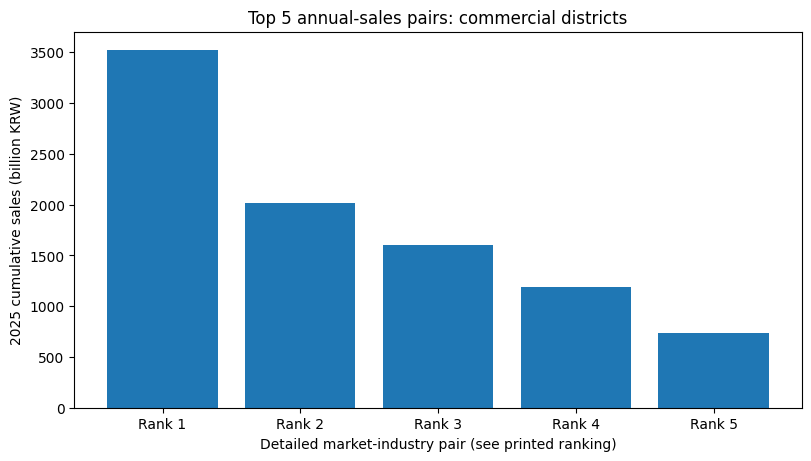

In [6]:
# 4. Visualize the results.
# This code follows ComPhy-3-Matplotlib.ipynb:
# fig, ax = plt.subplots(), ax.bar(), ax.plot(), ax.legend()

selected_type = "발달상권"
top5 = top_records_in_type(records, selected_type, 5)

labels = []
values = []
rank = 1

for item in top5:
    labels.append("Rank " + str(rank))
    values.append(item[0] / 1000000000.0)
    rank = rank + 1

fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")
ax.bar(labels, values)
ax.set_title("Top 5 annual-sales pairs: commercial districts")
ax.set_xlabel("Detailed market-industry pair (see printed ranking)")
ax.set_ylabel("2025 cumulative sales (billion KRW)")
plt.show()


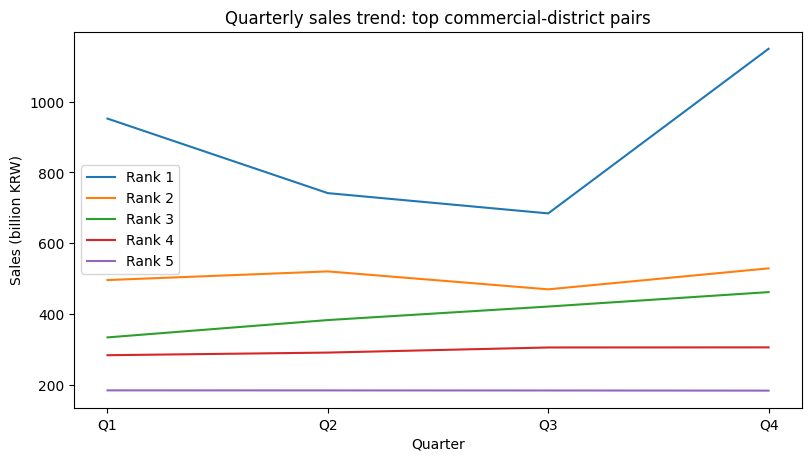

In [7]:
# Q1-Q4 trend for the same five pairs.
quarters = ["Q1", "Q2", "Q3", "Q4"]

fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")

rank = 1
for item in top5:
    q_sales = [
        item[5] / 1000000000.0,
        item[6] / 1000000000.0,
        item[7] / 1000000000.0,
        item[8] / 1000000000.0
    ]
    ax.plot(quarters, q_sales, label="Rank " + str(rank))
    rank = rank + 1

ax.set_title("Quarterly sales trend: top commercial-district pairs")
ax.set_xlabel("Quarter")
ax.set_ylabel("Sales (billion KRW)")
ax.legend()
plt.show()


## 해석 시 주의

- 이 분석은 **추정 매출 성과**를 보여 주며 임대료, 인건비, 폐업률, 점포 수가 없으므로 `수익성`이나 `창업 성공`을 보장하지 않는다.
- 관광특구·발달상권처럼 상권 구분 간 지리적 범위가 겹칠 수 있어, 서로 다른 상권 유형의 총매출을 합산해 서울 전체 매출처럼 해석하지 않는다.
- 그래서 LQ와 상위 10% 기준은 반드시 **동일한 상권 구분 안에서** 계산했다.